In [2]:
%display latex

# Transmission à n antennes

 ## Passage des matrices aux vecteurs et vice-versa

In [3]:
M = [
[1,1,0,1],
[0,1,0,0],
[0,0,1,1],
[0,1,0,0],
[1,0,1,0]
]; Mtemoin=Matrix(M); Mtemoin

[1 1 0 1]
[0 1 0 0]
[0 0 1 1]
[0 1 0 0]
[1 0 1 0]

In [4]:
def randmessage(m,n):
    '''
    Entrées :
    m : nombre de bits dans un message
    n : nombre d'antennes
    Sortie :
    Matrice aléatoire de taille m x n
    '''
    return random_matrix(GF(2),m,n)

In [5]:
randmessage(5,4)

[0 0 1 0]
[1 0 1 1]
[1 0 1 1]
[0 1 1 1]
[0 1 1 0]

In [6]:
#Exemple sur F_2^5

In [7]:
R.<x> = PolynomialRing(GF(2))

In [8]:
P = x^5 + x^2 + 1

In [9]:
P.is_irreducible()

True

In [10]:
K = GF(2^5, name='x', modulus=x^5+x^2+1); K

Finite Field in x of size 2^5

In [11]:
y = K(x); y.parent()

Finite Field in x of size 2^5

In [12]:
def matrice_v_vecteur_naif(M):
    vecteur = []
    for L in transpose(M):
        S = sum([L[i]*y^i for i in range(len(L))])
        vecteur+=[S]
    return vecteur

In [13]:
vtemoin = matrice_v_vecteur_naif(Mtemoin); vtemoin

[x^4 + 1, x^3 + x + 1, x^4 + x^2, x^2 + 1]

In [14]:
vtemoin[0].parent()

Finite Field in x of size 2^5

In [15]:
#Passage d'une matrice à un vecteur

In [16]:
def matrice_v_vecteur(M):
    '''
    Entrées :
    M : matrice de taille m x n
    Sortie :
    vecteur : vecteur de taille n représentant les colonnes de M dans la base de F_(2^m) automatiquement choisie par Sage
    '''
    m = M.nrows()
    n = M.ncols()
    K = GF(2^m)
    R.<x> = PolynomialRing(GF(2))
    y = K(x)
    vecteur = []
    for L in transpose(M):
        S = sum([L[i]*y^i for i in range(m)])
        vecteur+=[S]
    return vecteur

In [17]:
M = randmessage(8,5); M

[1 0 1 0 0]
[0 1 0 0 0]
[1 0 1 1 1]
[0 1 0 1 1]
[1 1 0 0 0]
[0 1 1 1 0]
[0 0 0 0 1]
[0 1 0 0 0]

In [18]:
matrice_v_vecteur(M)

[z8^4 + z8^2 + 1,
 z8^7 + z8^5 + z8^4 + z8^3 + z8,
 z8^5 + z8^2 + 1,
 z8^5 + z8^3 + z8^2,
 z8^6 + z8^3 + z8^2]

In [19]:
M = randmessage(8,15); M

[0 0 1 1 0 0 1 1 0 0 0 0 0 1 1]
[1 0 0 0 0 1 0 0 0 1 1 0 1 0 1]
[1 1 0 1 0 1 0 0 0 0 0 0 1 0 1]
[1 0 0 0 1 1 0 1 1 1 0 1 1 0 0]
[1 0 1 1 1 0 1 0 0 0 1 0 1 1 0]
[0 1 0 0 1 1 0 1 1 1 0 1 0 0 0]
[1 0 1 1 1 0 0 1 1 0 0 0 1 0 1]
[1 0 0 1 0 0 0 0 1 0 1 1 1 1 1]

In [20]:
v = matrice_v_vecteur(M); v

[z8^7 + z8^6 + z8^4 + z8^3 + z8^2 + z8,
 z8^5 + z8^2,
 z8^6 + z8^4 + 1,
 z8^7 + z8^6 + z8^4 + z8^2 + 1,
 z8^6 + z8^5 + z8^4 + z8^3,
 z8^5 + z8^3 + z8^2 + z8,
 z8^4 + 1,
 z8^6 + z8^5 + z8^3 + 1,
 z8^7 + z8^6 + z8^5 + z8^3,
 z8^5 + z8^3 + z8,
 z8^7 + z8^4 + z8,
 z8^7 + z8^5 + z8^3,
 z8^7 + z8^6 + z8^4 + z8^3 + z8^2 + z8,
 z8^7 + z8^4 + 1,
 z8^7 + z8^6 + z8^2 + z8 + 1]

In [21]:
#Passage d'un vecteur à une matrice

In [22]:
[coord.polynomial().list() for coord in v]

[[0, 1, 1, 1, 1, 0, 1, 1],
 [0, 0, 1, 0, 0, 1],
 [1, 0, 0, 0, 1, 0, 1],
 [1, 0, 1, 0, 1, 0, 1, 1],
 [0, 0, 0, 1, 1, 1, 1],
 [0, 1, 1, 1, 0, 1],
 [1, 0, 0, 0, 1],
 [1, 0, 0, 1, 0, 1, 1],
 [0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 1, 0, 1],
 [0, 1, 0, 0, 1, 0, 0, 1],
 [0, 0, 0, 1, 0, 1, 0, 1],
 [0, 1, 1, 1, 1, 0, 1, 1],
 [1, 0, 0, 0, 1, 0, 0, 1],
 [1, 1, 1, 0, 0, 0, 1, 1]]

In [23]:
def vecteur_v_matrice(v,m):
    '''
    Entrées :
    m : entier naturel
    v : vecteur de taille n à coefficients dans F_(2^m)
    Sortie :
    Matrice de taille m x n représentant les coefficients de v en colonnes dans la base de F_(2^m) automatiquement choisie par Sage
    '''
    Matrice=[]
    for coord in v:
        L = coord.polynomial().list()
        k = len(L)
        Lam = L + [0 for j in range(m-k)]
        Matrice+=[Lam]
    return transpose(Matrix(Matrice))

In [24]:
vecteur_v_matrice(v,8)

[0 0 1 1 0 0 1 1 0 0 0 0 0 1 1]
[1 0 0 0 0 1 0 0 0 1 1 0 1 0 1]
[1 1 0 1 0 1 0 0 0 0 0 0 1 0 1]
[1 0 0 0 1 1 0 1 1 1 0 1 1 0 0]
[1 0 1 1 1 0 1 0 0 0 1 0 1 1 0]
[0 1 0 0 1 1 0 1 1 1 0 1 0 0 0]
[1 0 1 1 1 0 0 1 1 0 0 0 1 0 1]
[1 0 0 1 0 0 0 0 1 0 1 1 1 1 1]

In [25]:
vecteur_v_matrice(v,8) == M

True

In [26]:
n=4
E = GF(2^8)^n; vec=E.random_element(); vec

(z8^7 + z8^6 + z8^3 + z8^2 + 1, z8^6 + z8^5 + z8^4 + z8 + 1, z8^7 + z8^5 + z8^3 + z8^2 + z8 + 1, z8^7 + z8^6 + z8^3 + z8)

In [27]:
vecteur_v_matrice(vec,8)

[1 1 1 0]
[0 1 1 1]
[1 0 1 0]
[1 0 1 1]
[0 1 0 0]
[0 1 1 0]
[1 1 0 1]
[1 0 1 1]

In [ ]:
#Attention, ces opérations dépendent du polynôme choisi pour construire le corps $F_2^n$ !

In [29]:
def matrice_v_vecteur_modele_1(M):
    m=6
    n = M.ncols()
    K = GF(2^m, name='x', modulus=x^6 + x^3 + 1)
    vecteur = []
    for L in transpose(M):
        S = sum([L[i]*x^i for i in range(m)])
        vecteur+=[S]
    return vecteur

def matrice_v_vecteur_modele_2(M):
    m=6
    n = M.ncols()
    K = GF(2^m, name='y', modulus=x^6 + x + 1)
    vecteur = []
    for L in transpose(M):
        S = sum([L[i]*y^i for i in range(m)])
        vecteur+=[S]
    return vecteur

In [30]:
M = randmessage(8,6); M

[1 0 0 1 0 1]
[1 0 0 0 0 1]
[1 0 1 0 0 0]
[1 0 1 1 1 1]
[1 1 1 1 1 0]
[1 1 1 0 1 1]
[1 0 0 1 0 1]
[0 1 1 0 1 0]

In [31]:
matrice_v_vecteur_modele_1(M)

[x^5 + x^4 + x^3 + x^2 + x + 1,
 x^5 + x^4,
 x^5 + x^4 + x^3 + x^2,
 x^4 + x^3 + 1,
 x^5 + x^4 + x^3,
 x^5 + x^3 + x + 1]

In [32]:
matrice_v_vecteur_modele_2(M)

[x^4 + x^3 + x,
 x^4 + x^2 + 1,
 x^4 + x^3 + 1,
 x^4 + x^3 + 1,
 x^4 + x^3 + x^2 + 1,
 x^3 + x^2 + x]

## Calcul de distances

In [33]:
def randmot(m,n):
    '''
    Entrées :
    m : nombre de bits dans un message
    n : nombre d'antennes
    Sortie :
    Vecteur aléatoire de taille n à coefficients dans F_(2^m)
    '''
    E = GF(2^m)^n
    return E.random_element()

In [34]:
randmot(8,15)

(z8^7 + z8^6 + z8^5 + z8^2 + z8, z8^5 + z8^4 + z8^3 + z8^2, z8^4 + z8^3 + z8^2, z8^7 + z8^6 + z8^3 + z8 + 1, z8^7 + z8^5 + z8^4 + z8^3 + z8^2, z8^7 + z8^2 + 1, z8^7 + z8^6 + z8^5 + z8^2 + z8, z8^6 + z8^3 + z8^2 + 1, z8^2, z8^7 + z8^6 + z8^5 + z8^2 + z8 + 1, z8^7 + z8^6 + z8^3 + z8 + 1, z8^5 + z8^4 + z8^3 + z8^2 + z8, z8^7 + z8^5 + z8^4 + z8^3 + z8, z8^5 + 1, z8^5 + z8 + 1)

In [35]:
def dr(x,y,m):
    '''
    Entrées :
    m : entier naturel
    x, y : vecteurs de même taille dans à n coefficients dans F_(2^m) (heuristiquement, dans un code)
    Sortie : 
    Distance en métrique rang entre x et y
    '''
    assert len(x)==len(y)
    return rank(vecteur_v_matrice(x-y,m))

In [36]:
mot1=randmot(8,8); mot2=randmot(8,8); dr(mot1,mot2,8)

7

In [37]:
L=[]
for i in range(1000):
    mot1=randmot(8,8)
    mot2=randmot(8,8)
    L+=[dr(mot1,mot2,8)]
L

[7,
 6,
 5,
 7,
 7,
 7,
 6,
 6,
 8,
 8,
 8,
 7,
 7,
 6,
 7,
 7,
 7,
 8,
 8,
 7,
 6,
 7,
 7,
 6,
 8,
 7,
 7,
 8,
 7,
 7,
 7,
 8,
 8,
 6,
 6,
 7,
 7,
 7,
 6,
 7,
 7,
 7,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 7,
 8,
 7,
 7,
 7,
 8,
 8,
 8,
 8,
 7,
 7,
 6,
 7,
 7,
 8,
 6,
 8,
 6,
 7,
 8,
 8,
 5,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 6,
 7,
 6,
 7,
 8,
 8,
 8,
 8,
 7,
 7,
 6,
 7,
 7,
 6,
 6,
 7,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 6,
 7,
 8,
 7,
 6,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 6,
 7,
 7,
 7,
 8,
 7,
 7,
 6,
 8,
 8,
 7,
 7,
 6,
 7,
 5,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 6,
 8,
 8,
 7,
 6,
 7,
 7,
 8,
 6,
 7,
 7,
 5,
 7,
 7,
 7,
 7,
 6,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 8,
 6,
 8,
 7,
 7,
 7,
 8,
 6,
 8,
 8,
 8,
 6,
 7,
 7,
 6,
 6,
 7,
 7,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 6,
 6,
 8,
 6,
 6,
 8,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 6,
 7,
 8,
 8,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 6,
 7,
 6,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 8,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 7,
 8,
 8,
 8,
 7,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 8,
 8,
 8,
 6,
 7,
 8,
 7,
 8,
 7,
 7,
 8,
 6,
 8,
 8,
 7,
 7,
 7,
 8,
 8,
 7,
 7,
 6,
 7,
 7,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 7,
 7,
 7,
 6,
 7,
 7,
 7,
 6,
 7,
 8,
 7,
 7,
 7,
 8,
 8,
 7,
 6,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 6,
 8,
 8,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 7,
 7,
 7,
 8,
 7,
 6,
 6,
 6,
 7,
 7,
 7,
 8,
 8,
 6,
 8,
 6,
 7,
 8,
 7,
 7,
 8,
 7,
 8,
 8,
 7,
 7,
 7,
 6,
 8,
 8,
 7,
 7,
 8,
 7,
 6,
 7,
 8,
 8,
 8,
 8,
 6,
 8,
 8,
 8,
 6,
 7,
 8,
 7,
 6,
 8,
 8,
 8,
 7,
 6,
 6,
 8,
 7,
 7,
 7,
 7,
 6,
 8,
 6,
 7,
 8,
 7,
 7,
 8,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 7,
 8,
 7,
 8,
 7,
 7,
 8,
 8,
 7,
 7,
 6,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 7,
 7,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 7,
 8,
 8,
 7,
 7,
 7,
 8,
 7,
 7,
 6,
 7,
 8,
 8,
 7,
 8,
 5,
 6,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 7,
 8,
 8,
 7,
 7,
 7,
 6,
 6,
 7,
 7,
 7,
 8,
 7,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 6,
 7,
 7,
 6,
 8,
 7,
 8,
 8,
 7,
 6,
 7,
 7,
 8,
 7,
 6,
 8,
 6,
 7,
 7,
 7,
 8,
 7,
 6,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 6,
 7,
 7,
 7,
 8,
 6,
 7,
 6,
 7,
 7,
 7,
 7,
 8,
 7,
 6,
 6,
 8,
 8,
 8,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 7,
 6,
 6,
 7,
 8,
 7,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 7,
 7,
 8,
 8,
 8,
 6,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 7,
 6,
 7,
 7,
 6,
 7,
 7,
 7,
 7,
 7,
 8,
 6,
 7,
 7,
 6,
 8,
 8,
 6,
 7,
 7,
 6,
 6,
 7,
 7,
 8,
 8,
 7,
 7,
 6,
 8,
 7,
 7,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 6,
 8,
 7,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 6,
 6,
 7,
 8,
 6,
 8,
 6,
 7,
 8,
 7,
 7,
 7,
 8,
 8,
 6,
 8,
 8,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 7,
 8,
 7,
 7,
 6,
 7,
 8,
 7,
 8,
 8,
 7,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 6,
 6,
 8,
 8,
 7,
 7,
 7,
 8,
 6,
 7,
 6,
 8,
 8,
 6,
 7,
 6,
 7,
 6,
 7,
 7,
 7,
 6,
 7,
 7,
 8,
 7,
 7,
 8,
 6,
 7,
 8,
 7,
 6,
 8,
 7,
 7,
 6,
 7,
 8,
 7,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 8,
 7,
 7,
 7,
 7,
 7,
 8,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 8,
 6,
 8,
 8,
 7,
 8,
 8,
 6,
 8,
 6,
 7,
 7,
 7,
 8,
 6,
 7,
 7,
 7,
 8,
 7,
 7,
 7,
 8,
 6,
 8,
 8,
 8,
 7,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 7,
 7,
 6,
 8,
 8,
 6,
 8,
 7,
 7,
 6,
 6,
 6,
 8,
 8,
 7,
 7,
 8,
 7,
 8,
 8,
 7,
 5,
 7,
 7,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 7,
 6,
 8,
 7,
 7,
 7,
 6,
 7,
 7,
 6,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 6,
 7,
 6,
 8,
 7,
 7,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 6,
 7,
 7,
 8,
 7,
 8,
 6,
 6,
 8,
 7,
 7,
 8,
 8,
 8,
 6,
 7,
 7,
 6,
 7,
 7,
 7,
 7,
 6,
 8,
 6,
 7,
 7,
 7,
 8,
 7,
 8,
 6,
 8,
 8,
 8,
 7,
 8,
 7,
 7,
 7,
 8,
 7,
 8,
 7,
 8,
 7,
 7,
 8,
 7,
 7,
 6,
 7,
 7,
 8,
 5,
 7]

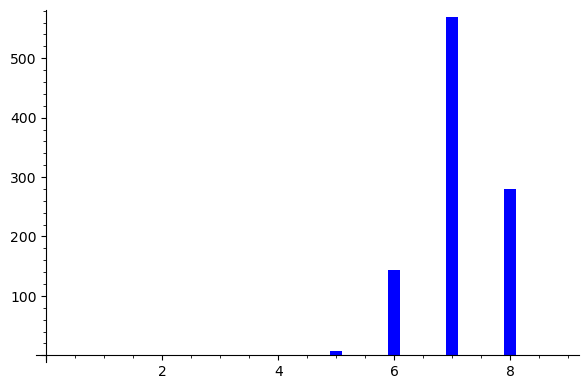

In [38]:
bar_chart([L.count(x) for x in range(0,9)], width=0.2)

In [39]:
@interact
def s(x0=slider(default=8,vmin=1,vmax=30)):
    L=[]
    for i in range(1000):
        mot1=randmot(8,x0)
        mot2=randmot(8,x0)
        L+=[dr(mot1,mot2,8)]
    return bar_chart([L.count(x) for x in range(0,x0+1)], width=0.2)

Interactive function <function s at 0x6ffd39505950> with 1 widget
  x0: TransformIntSlider(value=8, descriptio…

# Codes Gab

## Polynômes linéaires

In [ ]:
#Énumération de Lin(m) en degré <= k

In [41]:
def Lin(m,k):
    '''
    Entrées :
    m, k : entiers naturels
    Sortie :
    Liste des polynômes F_2-linéaires de <= k sur F_(2^m)
    '''
    K = GF(2^m)
    R.<X> = PolynomialRing(K)
    L=[]
    for u in K^k:
        P=sum([u[i]*X^(2^i) for i in range(k)])
        L+=[P]
    return L

In [42]:
Lin(1,4)

[0,
 X,
 X^2,
 X^2 + X,
 X^4,
 X^4 + X,
 X^4 + X^2,
 X^4 + X^2 + X,
 X^8,
 X^8 + X,
 X^8 + X^2,
 X^8 + X^2 + X,
 X^8 + X^4,
 X^8 + X^4 + X,
 X^8 + X^4 + X^2,
 X^8 + X^4 + X^2 + X]

In [43]:
Lin(2,3)

[0,
 z2*X,
 (z2 + 1)*X,
 X,
 z2*X^2,
 z2*X^2 + z2*X,
 z2*X^2 + (z2 + 1)*X,
 z2*X^2 + X,
 (z2 + 1)*X^2,
 (z2 + 1)*X^2 + z2*X,
 (z2 + 1)*X^2 + (z2 + 1)*X,
 (z2 + 1)*X^2 + X,
 X^2,
 X^2 + z2*X,
 X^2 + (z2 + 1)*X,
 X^2 + X,
 z2*X^4,
 z2*X^4 + z2*X,
 z2*X^4 + (z2 + 1)*X,
 z2*X^4 + X,
 z2*X^4 + z2*X^2,
 z2*X^4 + z2*X^2 + z2*X,
 z2*X^4 + z2*X^2 + (z2 + 1)*X,
 z2*X^4 + z2*X^2 + X,
 z2*X^4 + (z2 + 1)*X^2,
 z2*X^4 + (z2 + 1)*X^2 + z2*X,
 z2*X^4 + (z2 + 1)*X^2 + (z2 + 1)*X,
 z2*X^4 + (z2 + 1)*X^2 + X,
 z2*X^4 + X^2,
 z2*X^4 + X^2 + z2*X,
 z2*X^4 + X^2 + (z2 + 1)*X,
 z2*X^4 + X^2 + X,
 (z2 + 1)*X^4,
 (z2 + 1)*X^4 + z2*X,
 (z2 + 1)*X^4 + (z2 + 1)*X,
 (z2 + 1)*X^4 + X,
 (z2 + 1)*X^4 + z2*X^2,
 (z2 + 1)*X^4 + z2*X^2 + z2*X,
 (z2 + 1)*X^4 + z2*X^2 + (z2 + 1)*X,
 (z2 + 1)*X^4 + z2*X^2 + X,
 (z2 + 1)*X^4 + (z2 + 1)*X^2,
 (z2 + 1)*X^4 + (z2 + 1)*X^2 + z2*X,
 (z2 + 1)*X^4 + (z2 + 1)*X^2 + (z2 + 1)*X,
 (z2 + 1)*X^4 + (z2 + 1)*X^2 + X,
 (z2 + 1)*X^4 + X^2,
 (z2 + 1)*X^4 + X^2 + z2*X,
 (z2 + 1)*X^4 + X^2 + (z2 + 1)*X,
 (z2 + 1)*X^4 + X^2 + X,
 X^4,
 X^4 + z2*X,
 X^4 + (z2 + 1)*X,
 X^4 + X,
 X^4 + z2*X^2,
 X^4 + z2*X^2 + z2*X,
 X^4 + z2*X^2 + (z2 + 1)*X,
 X^4 + z2*X^2 + X,
 X^4 + (z2 + 1)*X^2,
 X^4 + (z2 + 1)*X^2 + z2*X,
 X^4 + (z2 + 1)*X^2 + (z2 + 1)*X,
 X^4 + (z2 + 1)*X^2 + X,
 X^4 + X^2,
 X^4 + X^2 + z2*X,
 X^4 + X^2 + (z2 + 1)*X,
 X^4 + X^2 + X]

In [45]:
def is_linear(P,m,k):
    return P in Lin(m,k)

In [46]:
m=3
R.<X> = PolynomialRing(GF(2^m))
is_linear(X^4 + X,3,4)

True

In [47]:
is_linear(X^3 + X,3,4)

False

In [ ]:
#Polynôme linéaire à racines prescrites

In [48]:
m=4
GF(2^m).random_element()

z4^2 + z4

In [50]:
def pol_prescrit(E,m):
    '''
    Entrées :
    m : entier naturel
    E : famille libre de k vecteurs sur F_(2^m)
    Sortie :
    Polynôme P dans Lin(m, k) tel que Z(P) = Vect
    '''
    k = len(E)
    assert k <= m
    R.<X> = PolynomialRing(GF(2^m))
    P = X^2 - E[0]*X
    for i in range(1,k):
        P = P^2 - P(E[i])*P
    return P

In [51]:
m = 4
M = randmessage(m,3); M

[0 1 0]
[0 1 0]
[1 1 1]
[0 1 0]

In [52]:
rank(M)

2

In [53]:
E = matrice_v_vecteur(M); E

[z4^2, z4^3 + z4^2 + z4 + 1, z4^2]

In [55]:
P = pol_prescrit(E,m); P

X^8 + (z4^3 + z4^2 + z4 + 1)*X^2

In [56]:
is_linear(P,m,m)

True

In [ ]:
for e in E:
    print(P(e))

## Construction de Gab_k

In [58]:
m = 6
M = randmessage(m,4); M

[1 0 1 1]
[0 1 1 0]
[0 0 0 1]
[0 1 1 0]
[1 0 0 0]
[1 1 0 0]

In [59]:
rank(M)

4

In [60]:
E = matrice_v_vecteur(M); E

[z6^5 + z6^4 + 1, z6^5 + z6^3 + z6, z6^3 + z6 + 1, z6^2 + 1]

In [61]:
P = pol_prescrit(E,m); P

X^16 + (z6^5 + z6^4 + z6 + 1)*X^8 + z6*X^4 + z6*X^2 + (z6^4 + z6^3 + z6)*X

In [62]:
for e in E:
    print(P(e))

0
0
0
0


In [63]:
n = len(E); n

4

In [65]:
k=3
g = E
gprime = g[:k]; gprime

[z6^5 + z6^4 + 1, z6^5 + z6^3 + z6, z6^3 + z6 + 1]

In [66]:
Polynomes = []
for i in range(1,k+1):
    gseconde = gprime[:i-1]+gprime[i:]
    print(gseconde)
    Polynomes+=[pol_prescrit(gseconde,m)]
Polynomes

[z6^5 + z6^3 + z6, z6^3 + z6 + 1]
[z6^5 + z6^4 + 1, z6^3 + z6 + 1]
[z6^5 + z6^4 + 1, z6^5 + z6^3 + z6]


[X^4 + (z6^5 + z6^3 + 1)*X^2 + (z6^5 + z6^4 + z6^3 + z6 + 1)*X,
 X^4 + (z6^4 + z6^3)*X^2 + (z6^5 + z6^4 + z6^3 + z6)*X,
 X^4 + (z6^5 + z6^4 + z6^3 + z6^2 + 1)*X^2 + (z6^2 + z6)*X]

In [67]:
for e in gprime:
    print(Polynomes[0](e))

z6^4
0
0


In [68]:
for e in gprime:
    print(Polynomes[1](e))

0
z6^4 + z6^2 + z6 + 1
0


In [69]:
for e in gprime:
    print(Polynomes[2](e))

0
0
z6^5 + z6^4 + z6^2 + z6 + 1


In [70]:
G = []
for i in range(k):
    L = []
    for j in range(n):
        L+=[Polynomes[i](g[j])]
    G+=[L]
Matrix(G)

[                       z6^4                           0                           0     z6^5 + z6^4 + z6^2 + z6]
[                          0        z6^4 + z6^2 + z6 + 1                           0                        z6^4]
[                          0                           0 z6^5 + z6^4 + z6^2 + z6 + 1            z6^5 + z6^3 + z6]

In [71]:
def Gab(k,g,m):
    '''
    Entrées :
    k, m : entiers naturels
    g : famille libre de n > k vecteurs sur F_(2^m)
    Sortie :
    Matrice génératrice du code Gab_k(g) sur F_(2^m), à k lignes et n colonnes
    '''
    n = len(g)
    assert n <= m
    gprime = g[:k]
    Polynomes = []
    for i in range(1,k+1):
        gseconde = gprime[:i-1]+gprime[i:]
        Polynomes+=[pol_prescrit(gseconde,m)]
    G = []
    for i in range(k):
        L = []
        for j in range(n):
            L+=[Polynomes[i](g[j])]
        G+=[L]
    return transpose(Matrix(G))

In [72]:
transpose(Gab(k,E,m))

[                       z6^4                           0                           0     z6^5 + z6^4 + z6^2 + z6]
[                          0        z6^4 + z6^2 + z6 + 1                           0                        z6^4]
[                          0                           0 z6^5 + z6^4 + z6^2 + z6 + 1            z6^5 + z6^3 + z6]

In [73]:
def code(mot, G):
    '''
    Entrées :
    mot : mot de taille k
    G : code Gab_k
    Sortie :
    codage du mot mot par le code G
    '''
    return G*transpose(Matrix(list(mot)))

In [74]:
mot = randmot(m,k); transpose(Matrix(list(mot)))

[z6^5 + z6^4 + z6^3 + z6 + 1]
[     z6^5 + z6^3 + z6^2 + 1]
[         z6^4 + z6^3 + z6^2]

In [75]:
code(mot, Gab(k,E,m))

[            z6^2]
[z6^5 + z6^2 + z6]
[        z6^5 + 1]
[ z6^5 + z6^3 + 1]